<a href="https://colab.research.google.com/github/Dandyeriametor/Activity/blob/main/Assignment_8_Supervised_Learning_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 8: Supervised Learning Classification

Author: Dandy Eriametor

Business Intelligence Analyst

Student Number: DE111080


Supervised Learning: Wine Quality Prediction (Regression)

In [1]:
# Import all the required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
# --- ML Models and Metrics ---
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (6, 4)

# Task 1: Dataset Selection and Loading

In [2]:
# Load Wine Quality dataset (Red Wine)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print(" Dataset Loaded Successfully!")
print("Shape:", df.shape)
df.head()


 Dataset Loaded Successfully!
Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# Task 2: Data Preprocessing

In [3]:
# Check for missing/null values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for duplicates
print("\nNumber of Duplicates:", df.duplicated().sum())

# Remove duplicates if any
df.drop_duplicates(inplace=True)

# Basic info
print("\nDataset Info:")
print(df.info())


Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Number of Duplicates: 240

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   residual sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free sulfur dioxide   1359 non-null   float64
 6   total sulfur dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8  

# Task 3: Exploratory Data Analysis (EDA)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


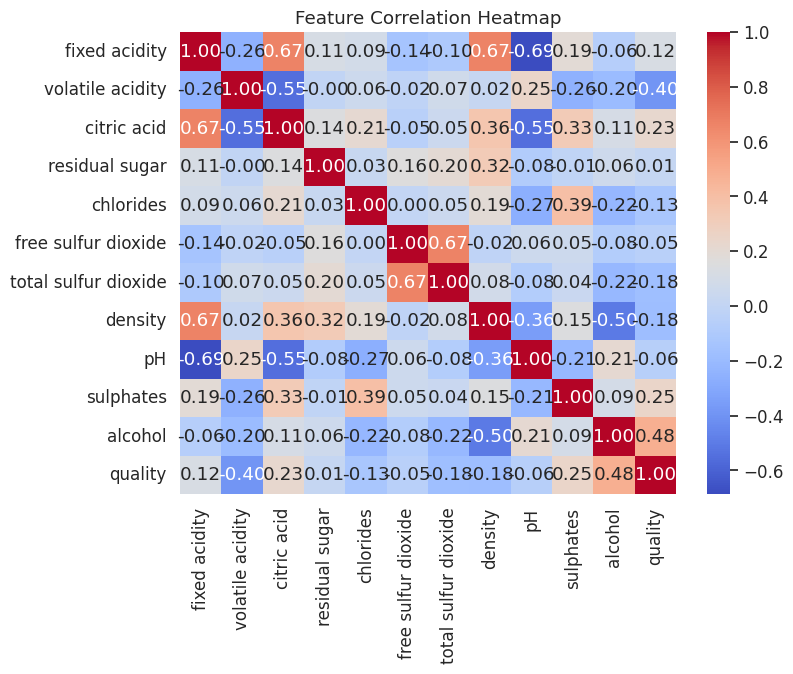

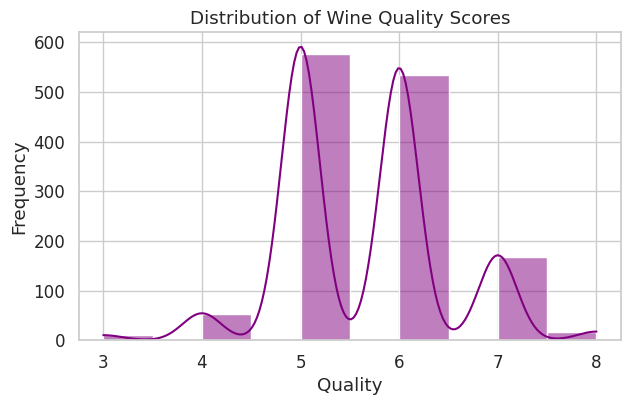

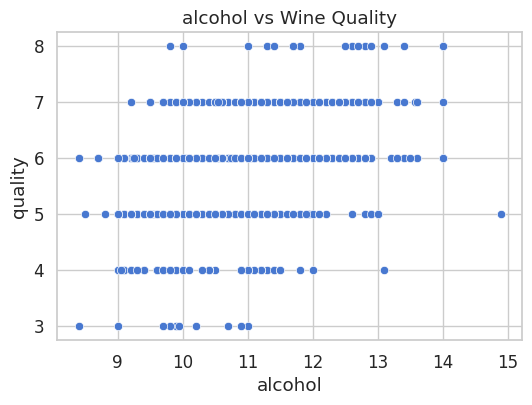

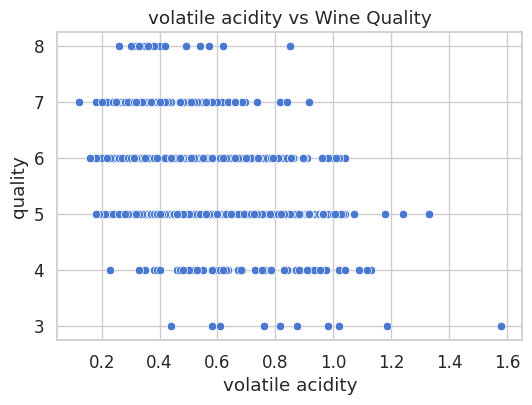

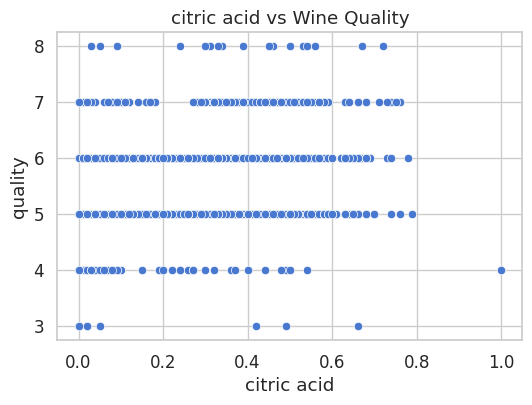

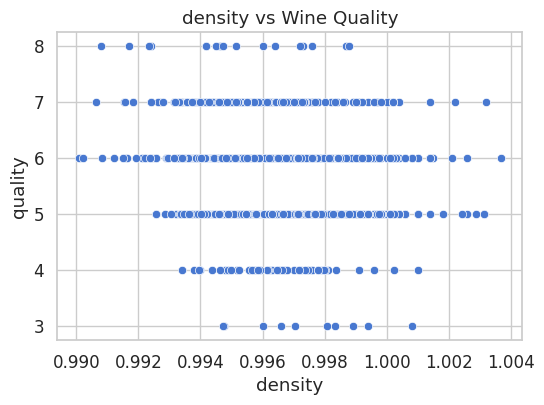

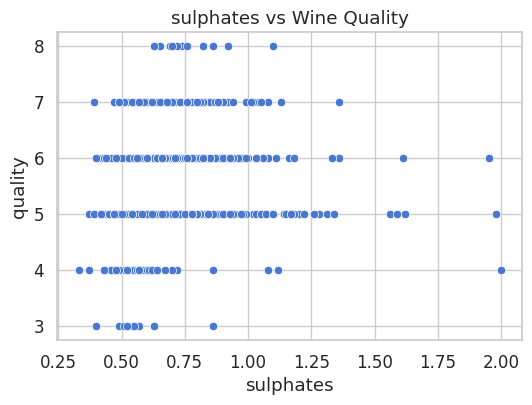

In [5]:
# Summary statistics
display(df.describe())

# Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Distribution of target variable (Quality)
plt.figure(figsize=(7, 4))
sns.histplot(df["quality"], bins=10, kde=True, color="purple")
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality")
plt.ylabel("Frequency")
plt.show()

# Scatter plots for some relationships
features_to_plot = ["alcohol", "volatile acidity", "citric acid", "density", "sulphates"]
for col in features_to_plot:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[col], y=df["quality"])
    plt.title(f"{col} vs Wine Quality")
    plt.show()

# Task 4: Data Splitting

In [6]:
# Define features (X) and target (y)
X = df.drop("quality", axis=1)
y = df["quality"]

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (1087, 11)
Testing set: (272, 11)


# Task 5: Model Implementation - Decision Tree & Random Forest

In [7]:
# Initialize models
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(random_state=42)

# Train models
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Predictions
dt_preds = dt_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Task 6:  Model Evaluation

In [8]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"📊 {model_name} Performance:")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R² Score: {r2:.3f}\n")
    return rmse, r2

dt_rmse, dt_r2 = evaluate_model(y_test, dt_preds, "Decision Tree")
rf_rmse, rf_r2 = evaluate_model(y_test, rf_preds, "Random Forest")

📊 Decision Tree Performance:
  RMSE: 0.945
  R² Score: -0.261

📊 Random Forest Performance:
  RMSE: 0.619
  R² Score: 0.458



# Task 7: Parameter Tuning (Optional)

In [9]:
# Grid search for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    rf_model, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("Best Parameters for Random Forest:", grid_search.best_params_)

# Evaluate best model
best_rf = grid_search.best_estimator_
best_rf_preds = best_rf.predict(X_test)
evaluate_model(y_test, best_rf_preds, "Tuned Random Forest")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}
📊 Tuned Random Forest Performance:
  RMSE: 0.607
  R² Score: 0.480



(np.float64(0.6068803641830253), 0.48005826329564216)

# Task 8: Model Interpretation

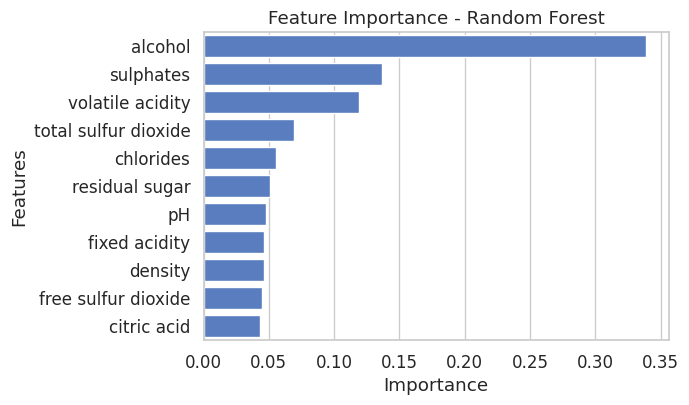

In [13]:
# Feature importance
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(6, 4))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

# Task 9: Model Prediction Example

In [11]:
sample = X_test.iloc[[0]]
print("\nSample Input Features:")
display(sample)

predicted_quality = best_rf.predict(sample)
print(f"🍷 Predicted Wine Quality: {predicted_quality[0]:.2f}")


Sample Input Features:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
55,7.7,0.62,0.04,3.8,0.084,25.0,45.0,0.9978,3.34,0.53,9.5


🍷 Predicted Wine Quality: 5.05


# Task 10: Deployment & Monitoring Discussion

In [12]:
"""
 Deployment Strategy:
- Save model using joblib or pickle.
- Create a REST API using Flask or FastAPI to serve predictions.
- Host on cloud (AWS, Azure, GCP) or local server.
- Build a simple web interface or integrate with an existing app.

 Monitoring Strategy:
- Log incoming requests and predictions.
- Monitor drift in feature distributions.
- Schedule regular retraining as new data arrives.
- Use dashboards (e.g., Grafana, Prometheus) for real-time model metrics.

 Potential Issues:
- Data drift (changing wine quality patterns)
- Model degradation over time
- Performance bottlenecks under heavy load
"""

'\n Deployment Strategy:\n- Save model using joblib or pickle.\n- Create a REST API using Flask or FastAPI to serve predictions.\n- Host on cloud (AWS, Azure, GCP) or local server.\n- Build a simple web interface or integrate with an existing app.\n\n Monitoring Strategy:\n- Log incoming requests and predictions.\n- Monitor drift in feature distributions.\n- Schedule regular retraining as new data arrives.\n- Use dashboards (e.g., Grafana, Prometheus) for real-time model metrics.\n\n Potential Issues:\n- Data drift (changing wine quality patterns)\n- Model degradation over time\n- Performance bottlenecks under heavy load\n'